# Exploración de hiperparámetros

Comparación manual de optimizadores y tasas de aprendizaje. Los resultados dependen de época/lote fijos y no constituyen búsqueda automática.


# Preparación de datos MNIST

In [6]:
# Librerías, semilla y carga de MNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_dev, y_train, y_dev = train_test_split(
    x_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)
x_train = x_train.astype("float32") / 255.0
x_dev = x_dev.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Train:", x_train.shape, "Dev:", x_dev.shape, "Test:", x_test.shape)


TensorFlow: 2.21.0
Train: (48000, 28, 28) Dev: (12000, 28, 28) Test: (10000, 28, 28)


# FUNCIÓN PARA CREAR MODELOS DE EXPERIMENTO
Esta función construye la misma arquitectura del baseline,
pero recibe el optimizador como parámetro para poder comparar alternativas.
De esta forma, solamente cambia el optimizador y el resto de condiciones se mantiene controlado.


In [7]:
def crear_modelo_experimento(optimizador, units=128):
    modelo = keras.Sequential([layers.Input(shape=(28, 28)), layers.Flatten(),
        layers.Dense(units, activation="relu"), layers.Dense(10, activation="softmax")])
    modelo.compile(optimizer=optimizador, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo


# COMPARACIÓN DE OPTIMIZADORES
Se crean fábricas para generar tres optimizadores: SGD con momentum, RMSprop y Adam.
Cada modelo se entrena por separado con las mismas condiciones.
clear_session libera el estado anterior de Keras y la semilla vuelve a fijarse.
Se almacenan las historias de entrenamiento y las métricas finales en una tabla.
Esto permite comparar accuracy de entrenamiento, accuracy de validación y validation loss.


In [8]:
fabricas_optimizadores = {

    "SGD_momentum": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.9
    ),

    "RMSprop": lambda: keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": lambda: keras.optimizers.Adam(
        learning_rate=0.001
    )

}

resultados_opt = []
historias_opt = {}

for nombre, fabrica in fabricas_optimizadores.items():

    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    modelo = crear_modelo_experimento(fabrica())

    historia = modelo.fit(
        x_train, y_train,
        validation_data=(x_dev, y_dev),
        epochs=5,
        batch_size=64,
        verbose=0
    )

    historias_opt[nombre] = historia

    resultados_opt.append({
    
        "optimizador": nombre,
        "train_accuracy": historia.history["accuracy"][-1],
        "dev_accuracy": historia.history["val_accuracy"][-1],
        "dev_loss": historia.history["val_loss"][-1]
    
    })

tabla_opt = pd.DataFrame(resultados_opt)
display(tabla_opt)

,optimizador,train_accuracy,dev_accuracy,dev_loss
0,SGD_momentum,0.966271,0.958250,0.141563
1,RMSprop,0.979792,0.968250,0.109351
2,Adam,0.982083,0.964667,0.117832


# GRÁFICA COMPARATIVA DE OPTIMIZADORES
Se dibuja la validation loss de cada optimizador a lo largo de las épocas.
Una curva menor indica menor pérdida sobre el conjunto de desarrollo.
La gráfica permite observar diferencias en velocidad de aprendizaje y estabilidad.


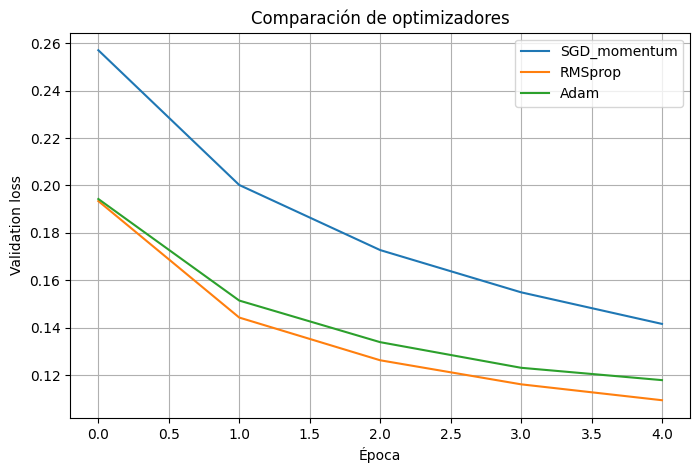

In [9]:
plt.figure(figsize=(8, 5))

for nombre, historia in historias_opt.items():
    plt.plot(historia.history["val_loss"], label=nombre)



plt.xlabel("Época")
plt.ylabel("Validation loss")
plt.title("Comparación de optimizadores")
plt.legend()
plt.grid(True)
plt.show()

# EXPERIMENTO CON LEARNING RATE
Se prueban tres tasas de aprendizaje para Adam.
Cada valor se evalúa en un modelo nuevo para mantener independientes los experimentos.
Se registran las métricas finales para determinar qué tasa funciona mejor bajo estas condiciones.


In [10]:
learning_rates = [0.0001, 0.001, 0.01]
resultados_lr = []



for lr in learning_rates:

    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    modelo = crear_modelo_experimento(

        keras.optimizers.Adam(learning_rate=lr)

    )

    historia = modelo.fit(

        x_train, y_train,
        validation_data=(x_dev, y_dev),
        epochs=3,
        batch_size=64,
        verbose=0

    )

    resultados_lr.append({

        "learning_rate": lr,
        "train_accuracy": historia.history["accuracy"][-1],
        "dev_accuracy": historia.history["val_accuracy"][-1],
        "dev_loss": historia.history["val_loss"][-1]

    })

display(pd.DataFrame(resultados_lr))

,learning_rate,train_accuracy,dev_accuracy,dev_loss
0,0.0001,0.918500,0.922833,0.281903
1,0.0010,0.969500,0.960167,0.131901
2,0.0100,0.968521,0.959250,0.154741
